# S1 Score

The S1 score (Teweles and Wobus, 1954) is a traditional verification measure used by the WMO to assess how well a forecast reproduces the *spatial gradient* (i.e. the pattern) of a field, rather than simply its pointwise magnitude. It is particularly useful for evaluating fields like mean sea level pressure or geopotential height, where getting the gradient (and hence the wind and pressure pattern) right matters more than getting the exact magnitude right everywhere.

The S1 score is defined as

$$\text{S1} = 100 \cdot \frac{\sum_{i=1}^n w_i (eg)_i}{\sum_{i=1}^n w_i (GL)_i}$$

where:

- $x_f$ = the forecast value of the parameter in question
- $x_v$ = the corresponding verifying (observed/analysed) value
- $n$ = the number of grid points or observations in the verification area
- $w_i$ = the weight applied at grid point or observation location $i$

The gradients are approximated by differences computed on the verification grid:

$$eg = \left| \frac{\partial}{\partial x}(x_f - x_v) \right| + \left| \frac{\partial}{\partial y}(x_f - x_v) \right|$$

$$GL = \max\left(\left|\frac{\partial x_f}{\partial x}\right|, \left|\frac{\partial x_v}{\partial x}\right|\right) + \max\left(\left|\frac{\partial x_f}{\partial y}\right|, \left|\frac{\partial x_v}{\partial y}\right|\right)$$

The weights applied at each grid point or observation location are defined as:

- **Verification against analyses:** $w_i = \cos\theta_i$, the cosine of latitude at grid point $i$.
- **Verification against observations:** $w_i = 1/n$, i.e. all observations have equal weight.

A lower S1 score indicates a better match between the spatial gradients of the forecast and the verifying field. A perfect forecast has an S1 score of 0. Historically, S1 scores below about 20 have been considered to indicate a highly skilful forecast, while scores above 70 indicate little to no skill, though these thresholds are somewhat dependent on the field and resolution being verified.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from scores.continuous import mse, s1
from scores.functions import create_latitude_weights

np.random.seed(42)  # Ensures consistent values across notebook runs


In [2]:
# Uncomment the line below to view detailed help information on the arguments to the s1 function
# help(s1)


## Setup

Since the S1 score is computed from spatial gradients, we need gridded data with genuine spatial structure (unlike many other tutorials that use independent random noise at each point).

We construct a synthetic observed field on a `lat x lon` grid made up of a smooth, large-scale wave pattern (e.g. representing a geopotential height anomaly field). We then create two forecasts of this field, both with a very similar overall error magnitude:

- **Forecast A (good gradients):** The observed field with a small, spatially-smooth/coherent error (a slightly damped amplitude plus a constant offset). The broad-scale gradient pattern of the field is well preserved.
- **Forecast B (noisy/poor gradients):** The observed field with independent, gridpoint-to-gridpoint random noise added. The broad-scale pattern is preserved, but fine-scale, unstructured noise is introduced at every grid point.

This lets us illustrate how S1 penalises a forecast for introducing spurious small-scale gradients (noise), even when simpler metrics like MSE consider the two forecasts to have very similar overall skill.


In [3]:
lats = np.linspace(-40, 40, 25)
lons = np.linspace(120, 170, 30)
lon_grid, lat_grid = np.meshgrid(lons, lats)

# A smooth, large-scale wave pattern representing e.g. a geopotential height anomaly field
obs_values = 8 * np.sin(2 * np.pi * (lon_grid - lons.min()) / (lons.max() - lons.min())) * np.cos(
    np.pi * lat_grid / 90
) + 4 * np.cos(2 * np.pi * (lat_grid - lats.min()) / (lats.max() - lats.min()))

obs = xr.DataArray(obs_values, coords={"lat": lats, "lon": lons}, dims=["lat", "lon"])

# Forecast A: a small, spatially-smooth/coherent error (damped amplitude plus a constant offset).
# The overall gradient pattern of the field is well preserved.
fcst_a = 0.85 * obs + 0.8

# Forecast B: the same field with spatially independent (unstructured) grid-point noise added.
# The broad-scale pattern is preserved, but fine-scale gridpoint-to-gridpoint noise is introduced.
noise = np.random.normal(scale=1.08, size=obs.shape)
fcst_b = xr.DataArray(obs.values + noise, coords={"lat": lats, "lon": lons}, dims=["lat", "lon"])


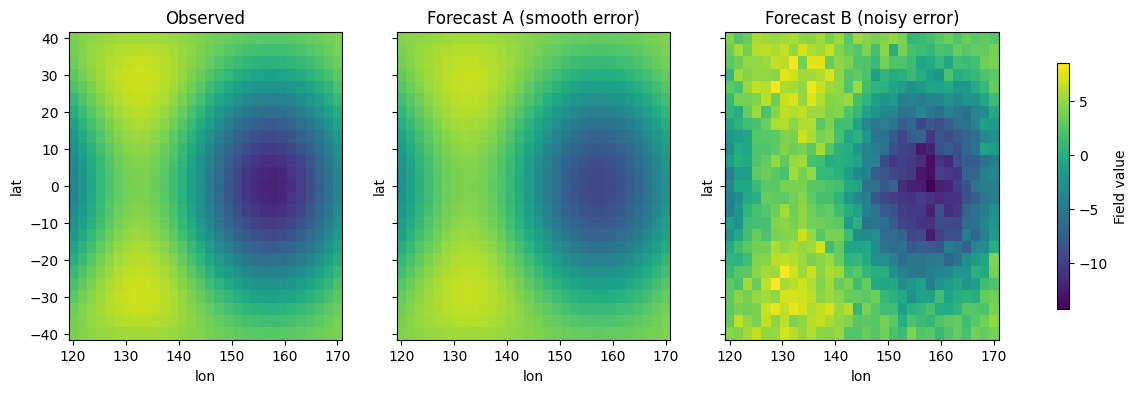

In [4]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

vmin = min(obs.min(), fcst_a.min(), fcst_b.min())
vmax = max(obs.max(), fcst_a.max(), fcst_b.max())

for ax, field, title in zip(axs, [obs, fcst_a, fcst_b], ["Observed", "Forecast A (smooth error)", "Forecast B (noisy error)"]):
    im = field.plot(ax=ax, x="lon", y="lat", vmin=vmin, vmax=vmax, add_colorbar=False)
    ax.set_title(title)

fig.colorbar(im, ax=axs, shrink=0.8, label="Field value")
plt.show()


Visually, Forecast A looks like a slightly weaker, offset version of the observed field but keeps its smooth structure, whereas Forecast B looks "speckled" or noisy on top of the same broad-scale pattern.

Let's compute the Mean Squared Error (MSE) and the S1 score for both forecasts.


In [5]:
mse_a = mse(fcst_a, obs).item()
mse_b = mse(fcst_b, obs).item()

s1_a = s1(fcst_a, obs, x_dim="lon", y_dim="lat").item()
s1_b = s1(fcst_b, obs, x_dim="lon", y_dim="lat").item()

print(f"Forecast A: MSE = {mse_a:.3f}, S1 = {s1_a:.2f}")
print(f"Forecast B: MSE = {mse_b:.3f}, S1 = {s1_b:.2f}")


Forecast A: MSE = 1.164, S1 = 15.00
Forecast B: MSE = 1.128, S1 = 78.13


Forecast A and Forecast B have almost identical MSE (around 1.1-1.2) &mdash; by that measure alone, they would be judged to have very similar skill, with Forecast B even scoring marginally better.

However, the S1 scores tell a very different story: Forecast A has a much lower (better) S1 score than Forecast B. This is because S1 measures how well the *gradient* (spatial pattern) of the field is reproduced. Forecast A's error is smooth and spatially coherent, so it barely disturbs the gradient structure of the field. Forecast B's error is unstructured, gridpoint-to-gridpoint noise, which creates many spurious local gradients that are not present in the observed field, even though its overall magnitude of error is no worse than Forecast A's.

This illustrates a key strength of the S1 score: it is sensitive to a lack of spatial coherence (e.g. "noisy" or "blocky" forecasts) in a way that simple pointwise scores like MSE and RMSE are not.

## Weighting

By default, `s1` uses equal weighting at each grid point/observation, which is appropriate when verifying against a set of observations (i.e. $w_i = 1/n$). When verifying against an analysis on a regular latitude/longitude grid, it is common to weight each grid point by the cosine of its latitude to account for the convergence of meridians towards the poles. This can be supplied using the `weights` argument, e.g. with `scores.functions.create_latitude_weights`.


In [6]:
weights = xr.DataArray(create_latitude_weights(lats), coords={"lat": lats}, dims=["lat"])

s1_a_weighted = s1(fcst_a, obs, x_dim="lon", y_dim="lat", weights=weights).item()
s1_b_weighted = s1(fcst_b, obs, x_dim="lon", y_dim="lat", weights=weights).item()

print(f"Forecast A: S1 (unweighted) = {s1_a:.2f}, S1 (cos-latitude weighted) = {s1_a_weighted:.2f}")
print(f"Forecast B: S1 (unweighted) = {s1_b:.2f}, S1 (cos-latitude weighted) = {s1_b_weighted:.2f}")


Forecast A: S1 (unweighted) = 15.00, S1 (cos-latitude weighted) = 15.00
Forecast B: S1 (unweighted) = 78.13, S1 (cos-latitude weighted) = 77.79


## Preserving dimensions

As with other `scores.continuous` functions, `s1` always reduces over the two spatial dimensions supplied via `x_dim` and `y_dim`, but any other dimensions present (e.g. `time` or an ensemble member dimension) can be preserved using `preserve_dims`, so that a separate S1 score is returned for each time step (or other preserved coordinate).


In [7]:
times = ["2024-01-01", "2024-01-02", "2024-01-03"]

# Stack three "time steps", with the noisy Forecast B becoming progressively noisier over time
fcst_b_series = xr.concat(
    [obs + np.random.normal(scale=sigma, size=obs.shape) for sigma in [0.5, 1.08, 2.0]],
    dim="time",
).assign_coords(time=times)
obs_series = xr.concat([obs] * 3, dim="time").assign_coords(time=times)

s1_by_time = s1(fcst_b_series, obs_series, x_dim="lon", y_dim="lat", preserve_dims="time")
s1_by_time


<xarray.DataArray (time: 3)> Size: 24B
array([52.2302881 , 77.39734389, 90.81944869])
Coordinates:
  * time     (time) <U10 120B '2024-01-01' '2024-01-02' '2024-01-03'

As expected, the S1 score increases (gets worse) with each successive time step, as the amount of unstructured grid-point noise in the forecast increases.

## Further Reading

- Teweles, S., & Wobus, H. B. (1954). Verification of prognostic charts. *Bulletin of the American Meteorological Society*, 35(9), 455-463. https://doi.org/10.1175/1520-0477-35.9.455
- World Meteorological Organization. *Manual on the Global Data-processing and Forecasting System.*


## Things to Try Next
- Compare S1 with RMSE or MSE on your own gridded forecast/observation data, to see whether the two scores agree or disagree.
- Try using `reduce_dims` instead of `preserve_dims` to control which dimensions the S1 score is computed over.
- Compare unweighted S1 scores to cosine-latitude-weighted scores on a grid that extends closer to the poles, where the weighting has a larger effect.
- Verify against point observations rather than a gridded analysis, in which case equal weights (`weights=None`) are typically appropriate.
